<a href="https://colab.research.google.com/github/FaraahJ/Data-Science-Internship-Assignments/blob/main/Wk4_Multi_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, log_loss, roc_auc_score, roc_curve
)
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn import tree
%matplotlib inline

In [139]:
df = pd.read_csv('/content/IRIS.csv')

In [140]:
print("Dataset Shape:", df.shape) #shows no. of rows and columns in dataset
print("\nFirst 5 Rows:")#displaying first 5 rows of dataset
df.head()

Dataset Shape: (129, 5)

First 5 Rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [141]:
#checking for missing values - ensures no bias/unreliable analysis
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [142]:
#no. of classes for data
pd.unique(df['species'])

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [143]:
#label encoding categorical classes into numerical classes of 0, 1 and 2
if df['species'].dtype == 'object':
    le = LabelEncoder()
    df['species'] = le.fit_transform(df['species'])

In [144]:
pd.unique(df['species'])

array([0, 1, 2])

In [145]:
print('number of samples in each class:')
df['species'].value_counts()

number of samples in each class:


,count
species,
0,50
1,50
2,29


In [146]:
#class 2 has less samples; use class weighting to balance out

from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(df['species']), y=df['species'])
class_weights_dict = {cls: weight for cls, weight in zip(np.unique(df['species']), class_weights)}

sample_weights = compute_sample_weight(class_weight=class_weights_dict, y=df['species'])

class_weights_dict

{np.int64(0): np.float64(0.86),
 np.int64(1): np.float64(0.86),
 np.int64(2): np.float64(1.4827586206896552)}

In [147]:
#splitting other features from target feature 'species' in x and y axis
X = df.drop('species', axis=1)
y = df['species']

#feature scaling in x axis to ensure all features have an equal mean of 0 and SD of 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [148]:
# splitting data in x axis, y axis and sample weights into training and testing data
#stratifying target feature in y prevents imbalance; train/test data samples have same proportion of class values as og dataset

X_train, X_test, y_train, y_test, sw_train, sw_test = train_test_split(X_scaled, y, sample_weights, test_size=0.3, stratify=y, random_state=42)


In [149]:
# Descriptive analysis
df.describe()


,sepal_length,sepal_width,petal_length,petal_width,species
count,129.000000,129.000000,129.000000,129.000000,129.000000
mean,5.716279,3.057364,3.476744,1.062791,0.837209
std,0.794983,0.453075,1.739231,0.727804,0.768427
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.500000,0.200000,0.000000
50%,5.600000,3.000000,4.000000,1.200000,1.000000
75%,6.300000,3.400000,4.800000,1.600000,1.000000
max,7.700000,4.400000,6.900000,2.500000,2.000000


In [150]:
# all dtypes are integers therefore no string indexing required
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  129 non-null    float64
 1   sepal_width   129 non-null    float64
 2   petal_length  129 non-null    float64
 3   petal_width   129 non-null    float64
 4   species       129 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 5.2 KB


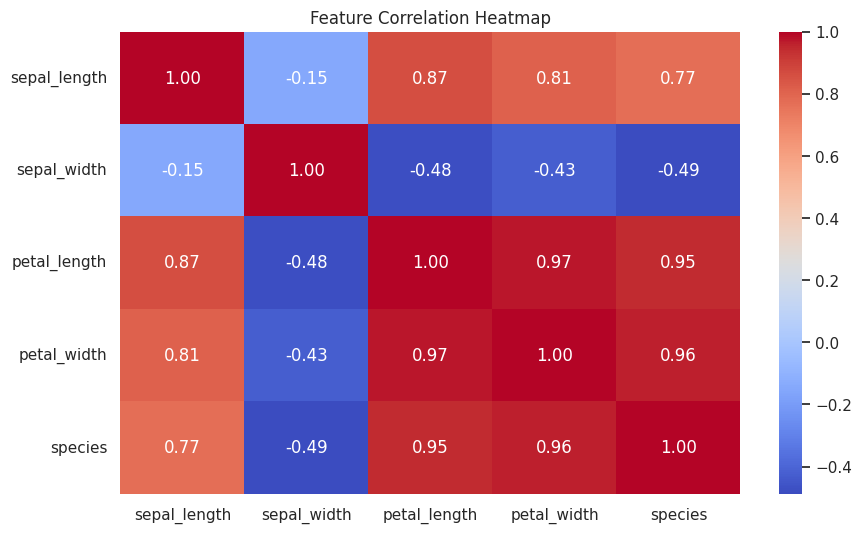

In [151]:
# EDA - Feature Correlation Heatmap
# strong positive correlation between petal length/petal width, and between species class and petal length/petal width
# strong negative correlation between sepal width and species class
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

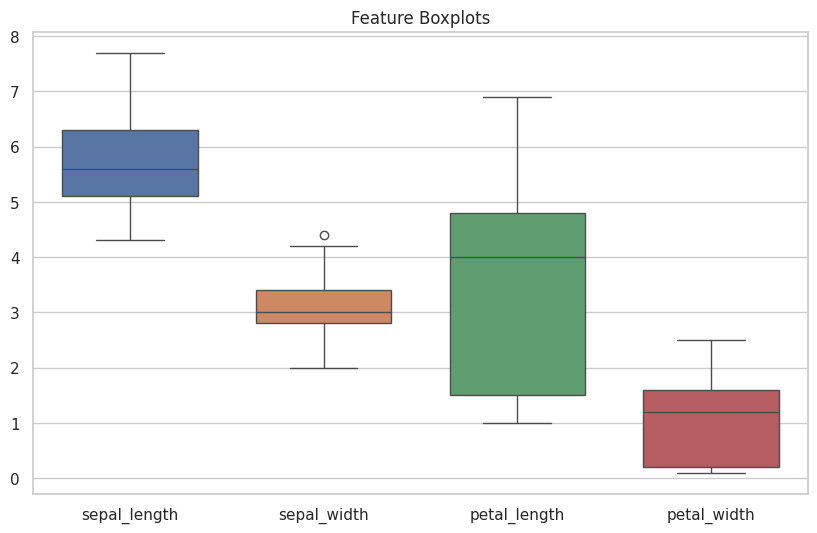

In [152]:
#EDA - Feature Boxplots


sns.set(style='whitegrid')

fig, ax = plt.subplots(figsize=(10,6))
g = sns.boxplot(data=df[
    ['sepal_length', 'sepal_width', 'petal_length', 'petal_width'
]], width=0.7)
plt.title('Feature Boxplots')

plt.show()

#single outlier for sepal width
#petal length has largest interquartile range

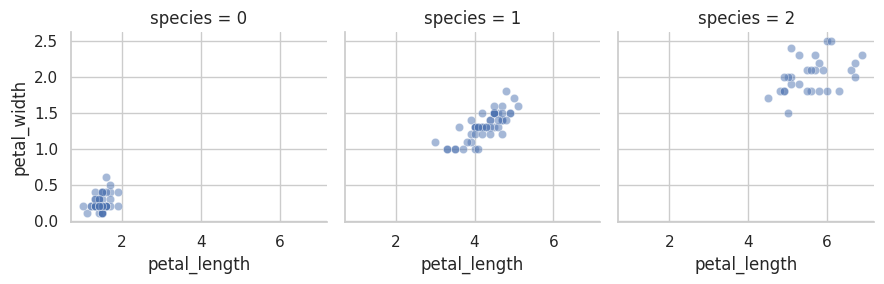

In [156]:
g = sns.FacetGrid(df, col='species');
g.map(sns.scatterplot, 'petal_length', 'petal_width', alpha=0.5)

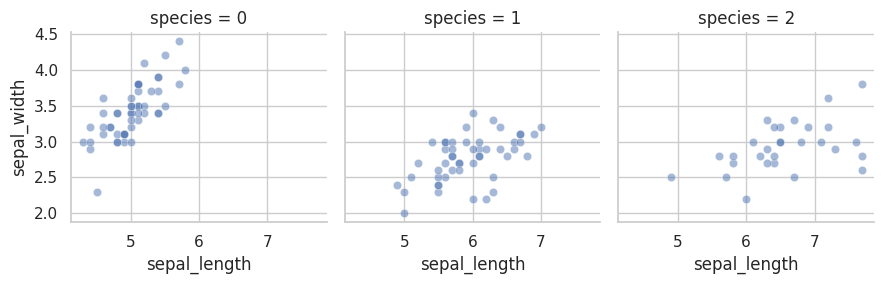

In [235]:
g = sns.FacetGrid(df, col='species');
g.map(sns.scatterplot, 'sepal_length', 'sepal_width', alpha=0.5)

In [157]:
# Multi Classification (no data balancing)
# 1vR Logistic Regression

lr_ovr = OneVsRestClassifier(LogisticRegression())
lr_ovr.fit(X_train, y_train)
y_pred_lr_ovr = lr_ovr.predict(X_test)

print("\nLogistic Regression (One-vs-Rest) Performance:")
print(classification_report(y_test, y_pred_lr_ovr))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr_ovr))

#recall - amount of actual postives classified as positive
#precision -  proportion of model's CORRECT positive classifications within all positive class
#f1-score - mean of precision and recall. useful for imbalanced datasets


Logistic Regression (One-vs-Rest) Performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.93      0.87      0.90        15
           2       0.80      0.89      0.84         9

    accuracy                           0.92        39
   macro avg       0.91      0.92      0.91        39
weighted avg       0.93      0.92      0.92        39

Confusion Matrix:
[[15  0  0]
 [ 0 13  2]
 [ 0  1  8]]


In [158]:
#enabling metadata routing into 1-v-rest classifier
from sklearn import set_config

set_config(enable_metadata_routing=True)

#1vR Logistic Regression (with balanced sample weights)
clf = OneVsRestClassifier(LogisticRegression(class_weight=class_weights_dict, max_iter=10000))
clf.estimator.set_fit_request(sample_weight=True)  # Requesting sample_weight
clf.fit(X_train, y_train, sample_weight=sw_train)

y_pred = clf.predict(X_test)

print("\nLogistic Regression (One-vs-Rest) Performance balanced weights:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

#values for balanced matrix have decreased
#class 0 has same values


Logistic Regression (One-vs-Rest) Performance balanced weights:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      0.60      0.75        15
           2       0.60      1.00      0.75         9

    accuracy                           0.85        39
   macro avg       0.87      0.87      0.83        39
weighted avg       0.91      0.85      0.85        39

Confusion Matrix:
[[15  0  0]
 [ 0  9  6]
 [ 0  0  9]]


In [168]:
#Evaluation Metrics
#y_true is training data for y
# Log Loss - measures how close predicted value is to actual value
def evaluate_model(y_true, y_pred, y_proba=None):
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    if y_proba is not None:
        print("Log Loss:", log_loss(y_true, y_proba))
        print("ROC AUC Score (OvR):", roc_auc_score(y_true, y_proba, multi_class='ovr'))

# 1vR evaluation
evaluate_model(y_test, y_pred_lr_ovr, lr_ovr.predict_proba(X_test))

#lower log loss (closer to 0) indicates better match

Confusion Matrix:
[[15  0  0]
 [ 0 13  2]
 [ 0  1  8]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.93      0.87      0.90        15
           2       0.80      0.89      0.84         9

    accuracy                           0.92        39
   macro avg       0.91      0.92      0.91        39
weighted avg       0.93      0.92      0.92        39

Log Loss: 0.31997430412578065
ROC AUC Score (OvR): 0.9817901234567902


In [159]:
# 1v1 logistic regression (no balance)
lr_ovo = OneVsOneClassifier(LogisticRegression())
lr_ovo.fit(X_train, y_train)
y_pred_lr_ovo = lr_ovo.predict(X_test)

print("\nLogistic Regression (One-vs-One) Performance:")
print(classification_report(y_test, y_pred_lr_ovo))


Logistic Regression (One-vs-One) Performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.94      1.00      0.97        15
           2       1.00      0.89      0.94         9

    accuracy                           0.97        39
   macro avg       0.98      0.96      0.97        39
weighted avg       0.98      0.97      0.97        39



In [160]:
#1v1 regression (with balanced samples)

clf = OneVsOneClassifier(LogisticRegression(class_weight=class_weights_dict, max_iter=10000))
clf.estimator.set_fit_request(sample_weight=True)
clf.fit(X_train, y_train, sample_weight=sw_train)

y_pred = clf.predict(X_test)

print("\nLogistic Regression (One-vs-One) Performance balanced weights:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Logistic Regression (One-vs-One) Performance balanced weights:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.93      0.93      0.93        15
           2       0.89      0.89      0.89         9

    accuracy                           0.95        39
   macro avg       0.94      0.94      0.94        39
weighted avg       0.95      0.95      0.95        39

Confusion Matrix:
[[15  0  0]
 [ 0 14  1]
 [ 0  1  8]]


In [231]:
# 1v1 Evaluation
# 1v1 does not support predict_proba
def evaluate_model(y_true, y_pred):
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))


evaluate_model(y_test, lr_ovo.predict(X_test))

Confusion Matrix:
[[15  0  0]
 [ 0 15  0]
 [ 0  1  8]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.94      1.00      0.97        15
           2       1.00      0.89      0.94         9

    accuracy                           0.97        39
   macro avg       0.98      0.96      0.97        39
weighted avg       0.98      0.97      0.97        39



In [213]:
#Softmax Regression (no balance)
softmax = LogisticRegression(multi_class='multinomial', solver='lbfgs')
softmax.fit(X_train, y_train)
y_pred_softmax = softmax.predict(X_test)

print("\nSoftmax Regression Performance:")
print(classification_report(y_test, y_pred_softmax))


Softmax Regression Performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.94      1.00      0.97        15
           2       1.00      0.89      0.94         9

    accuracy                           0.97        39
   macro avg       0.98      0.96      0.97        39
weighted avg       0.98      0.97      0.97        39



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [234]:
### Softmax (balanced)

clf = softmax(LogisticRegression(multi_class='multinomial', solver='lbfgs', class_weight=class_weights_dict, max_iter=10000))
clf.estimator.set_fit_request(sample_weight=True)
clf.fit(X_train, y_train, sample_weight=sw_train)

y_pred = clf.predict(X_test)


TypeError: 'LogisticRegression' object is not callable

In [ ]:
## evaluation for Softmax

In [164]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("\nDecision Tree Performance:")
evaluate_model(y_test, y_pred_dt, dt.predict_proba(X_test))

#log loss is high


Decision Tree Performance:
Confusion Matrix:
[[15  0  0]
 [ 0 15  0]
 [ 0  1  8]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.94      1.00      0.97        15
           2       1.00      0.89      0.94         9

    accuracy                           0.97        39
   macro avg       0.98      0.96      0.97        39
weighted avg       0.98      0.97      0.97        39

Log Loss: 0.9241962407465939
ROC AUC Score (OvR): 0.9745370370370371


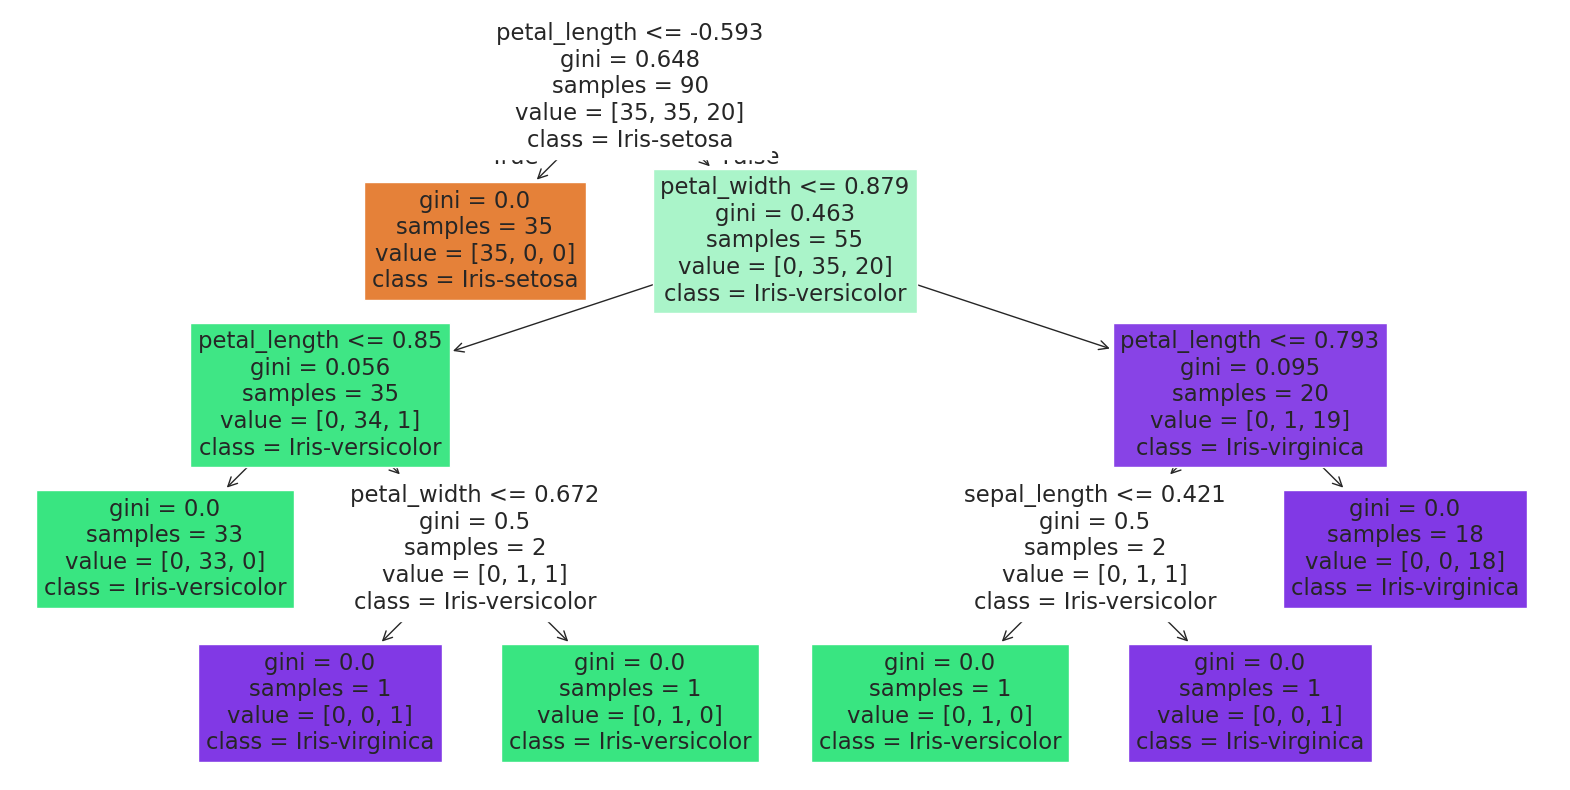

In [165]:
# Decision Tree Visual
plt.figure(figsize=(20, 10))
plot_tree(dt, filled=True, feature_names=X.columns, class_names=le.classes_)
plt.show()

In [166]:
#Model Comparison Chart
models = {
    'Logistic Regression (OvR)': lr_ovr,
    'Logistic Regression (OvO)': lr_ovo,
    'Softmax Regression': softmax,
    'Decision Tree': dt
}

metrics = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    # Check if the model is OneVsOneClassifier
    if name == 'Logistic Regression (OvO)':
        # OneVsOneClassifier does not support predict_proba
        metrics.append({
            'Model': name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, average='weighted'),
            'Recall': recall_score(y_test, y_pred, average='weighted'),
            'F1': f1_score(y_test, y_pred, average='weighted'),
            'Log Loss': 'Not Available',
            'ROC AUC (OvR)': 'Not Available'
        })
    else:
        # For other models, calculate predict_proba
        y_proba = model.predict_proba(X_test)
        metrics.append({
            'Model': name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, average='weighted'),
            'Recall': recall_score(y_test, y_pred, average='weighted'),
            'F1': f1_score(y_test, y_pred, average='weighted'),
            'Log Loss': log_loss(y_test, y_proba),
            'ROC AUC (OvR)': roc_auc_score(y_test, y_proba, multi_class='ovr')
        })

metrics_df = pd.DataFrame(metrics)
print("\nModel Comparison:")
metrics_df


Model Comparison:


,Model,Accuracy,Precision,Recall,F1,Log Loss,ROC AUC (OvR)
0,Logistic Regression (OvR),0.923077,0.926374,0.923077,0.923775,0.319974,0.98179
1,Logistic Regression (OvO),0.974359,0.975962,0.974359,0.974018,Not Available,Not Available
2,Softmax Regression,0.974359,0.975962,0.974359,0.974018,0.15615,1.0
3,Decision Tree,0.974359,0.975962,0.974359,0.974018,0.924196,0.974537


In [ ]:
# ROC AUC score - how well a model distinguishes between positive and negative classifications